In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [4]:
summary = pd.read_csv("student_summary.csv")

print("Dataset Loaded Successfully")
summary.head()

Dataset Loaded Successfully


,student_id,department,batch,status,login_frequency,avg_session_duration,student_segment,avg_progress,total_courses,courses_completed,questions,answers,comments,webinars_attended,events_participated,mentor_meetings,total_mentor_duration
0,ST001,Civil,2022,Inactive,18,53.777778,Moderate,42.5,2,0,7,9,39,4,2.0,1.0,29.0
1,ST002,Information Technology,2024,Inactive,8,50.875000,Moderate,41.0,3,0,4,20,11,1,1.0,0.0,0.0
2,ST003,Mechanical,2023,Active,12,62.250000,Moderate,57.0,3,0,9,19,21,2,1.0,1.0,20.0
3,ST004,Mechanical,2024,Inactive,12,57.250000,Moderate,62.6,5,0,2,1,29,5,1.0,2.0,135.0
4,ST005,Electronics,2024,Inactive,34,124.529412,Highly Active,87.0,4,3,20,29,67,4,5.0,0.0,0.0


In [5]:
print("Rows and Columns:")
print(summary.shape)

Rows and Columns:
(500, 17)


In [6]:
summary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             500 non-null    object 
 1   department             500 non-null    object 
 2   batch                  500 non-null    int64  
 3   status                 500 non-null    object 
 4   login_frequency        500 non-null    int64  
 5   avg_session_duration   500 non-null    float64
 6   student_segment        500 non-null    object 
 7   avg_progress           500 non-null    float64
 8   total_courses          500 non-null    int64  
 9   courses_completed      500 non-null    int64  
 10  questions              500 non-null    int64  
 11  answers                500 non-null    int64  
 12  comments               500 non-null    int64  
 13  webinars_attended      500 non-null    int64  
 14  events_participated    500 non-null    float64
 15  mentor

In [7]:
print("Missing Values")

summary.isnull().sum()

Missing Values


student_id               0
department               0
batch                    0
status                   0
login_frequency          0
avg_session_duration     0
student_segment          0
avg_progress             0
total_courses            0
courses_completed        0
questions                0
answers                  0
comments                 0
webinars_attended        0
events_participated      0
mentor_meetings          0
total_mentor_duration    0
dtype: int64

In [10]:
print("Duplicate Records:")

summary.duplicated().sum()

Duplicate Records:


np.int64(0)

In [11]:
summary.dtypes

student_id                object
department                object
batch                      int64
status                    object
login_frequency            int64
avg_session_duration     float64
student_segment           object
avg_progress             float64
total_courses              int64
courses_completed          int64
questions                  int64
answers                    int64
comments                   int64
webinars_attended          int64
events_participated      float64
mentor_meetings          float64
total_mentor_duration    float64
dtype: object

Basic Data Cleaning

In [12]:
# Remove duplicates if any

summary.drop_duplicates(inplace=True)

# Remove extra spaces from column names

summary.columns = summary.columns.str.strip()

print("Cleaning Completed")

Cleaning Completed


In [13]:
numeric_columns = [
    'login_frequency',
    'avg_session_duration',
    'avg_progress',
    'total_courses',
    'courses_completed',
    'questions',
    'answers',
    'comments',
    'webinars_attended',
    'events_participated',
    'mentor_meetings',
    'total_mentor_duration'
]

summary[numeric_columns] = summary[numeric_columns].apply(
    pd.to_numeric,
    errors='coerce'
)

print("Transformation Completed")

Transformation Completed


In [14]:
summary.describe()

,batch,login_frequency,avg_session_duration,avg_progress,total_courses,courses_completed,questions,answers,comments,webinars_attended,events_participated,mentor_meetings,total_mentor_duration
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2022.92600,14.062000,56.975927,53.461133,4.032000,0.752000,5.442000,10.852000,21.874000,2.518000,1.926000,1.446000,76.630000
std,0.81354,9.703735,35.757666,22.369374,1.386658,1.248043,4.797151,9.663999,17.943413,1.529167,1.407297,1.108848,65.153904
min,2022.00000,1.000000,6.000000,6.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2022.00000,6.000000,21.150000,31.750000,3.000000,0.000000,1.750000,3.000000,7.000000,1.000000,1.000000,0.000000,0.000000
50%,2023.00000,12.000000,53.964286,55.083333,4.000000,0.000000,4.500000,9.000000,20.000000,3.000000,2.000000,1.000000,72.000000
75%,2024.00000,19.000000,63.062500,68.333333,5.000000,1.000000,8.000000,16.250000,32.000000,4.000000,3.000000,2.000000,127.250000
max,2024.00000,40.000000,133.555556,93.333333,6.000000,6.000000,20.000000,40.000000,80.000000,5.000000,5.000000,3.000000,250.000000


In [15]:
summary["department"].value_counts()

department
Information Technology    107
Civil                     103
Mechanical                 99
Computer Science           97
Electronics                94
Name: count, dtype: int64

In [16]:
summary["student_segment"].value_counts()

student_segment
Moderate         250
At Risk          150
Highly Active    100
Name: count, dtype: int64

In [17]:
summary["status"].value_counts()

status
Inactive    260
Active      240
Name: count, dtype: int64

In [18]:
print("Average Login Frequency:",
      summary["login_frequency"].mean())

print("Average Course Progress:",
      summary["avg_progress"].mean())

print("Average Webinar Attendance:",
      summary["webinars_attended"].mean())

Average Login Frequency: 14.062
Average Course Progress: 53.46113333333333
Average Webinar Attendance: 2.518


Department-wise Average Progress

In [19]:
summary.groupby(
    "department"
)["avg_progress"].mean().sort_values(
    ascending=False
)

department
Electronics               55.092908
Mechanical                53.946633
Computer Science          53.821478
Civil                     52.921683
Information Technology    51.771028
Name: avg_progress, dtype: float64

Department-wise Login Frequency

In [20]:
summary.groupby(
    "department"
)["login_frequency"].mean().sort_values(
    ascending=False
)

department
Electronics               14.595745
Mechanical                14.090909
Civil                     14.048544
Computer Science          14.010309
Information Technology    13.626168
Name: login_frequency, dtype: float64

Student Segment Chart

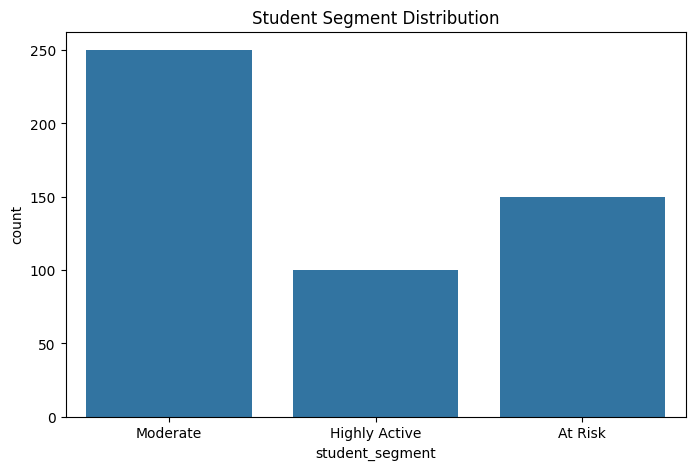

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=summary,
    x="student_segment"
)

plt.title("Student Segment Distribution")

plt.show()

Department Distribution Chart

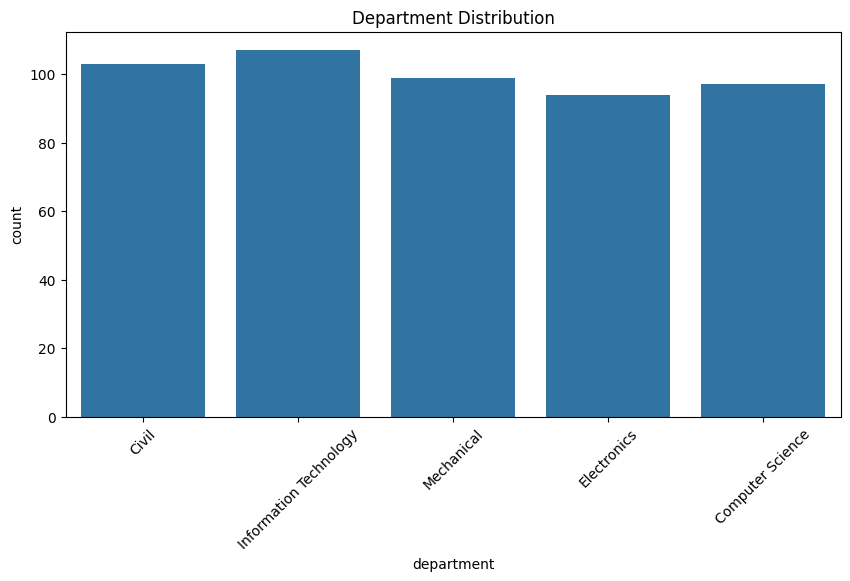

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=summary,
    x="department"
)

plt.xticks(rotation=45)

plt.title("Department Distribution")

plt.show()

Login Frequency Distribution

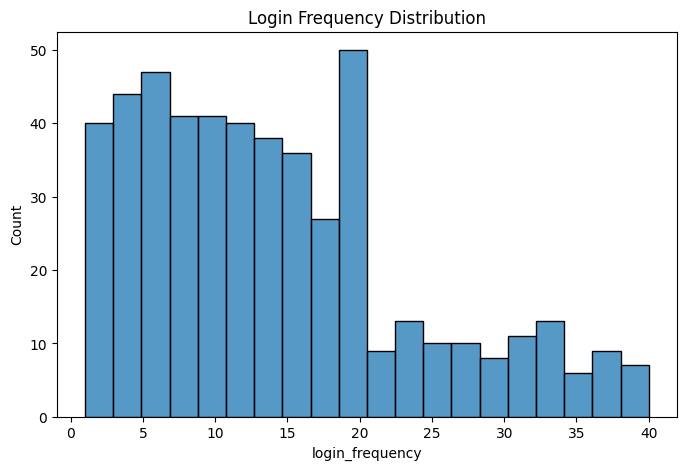

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    summary["login_frequency"],
    bins=20
)

plt.title("Login Frequency Distribution")

plt.show()

Correlation Heatmap

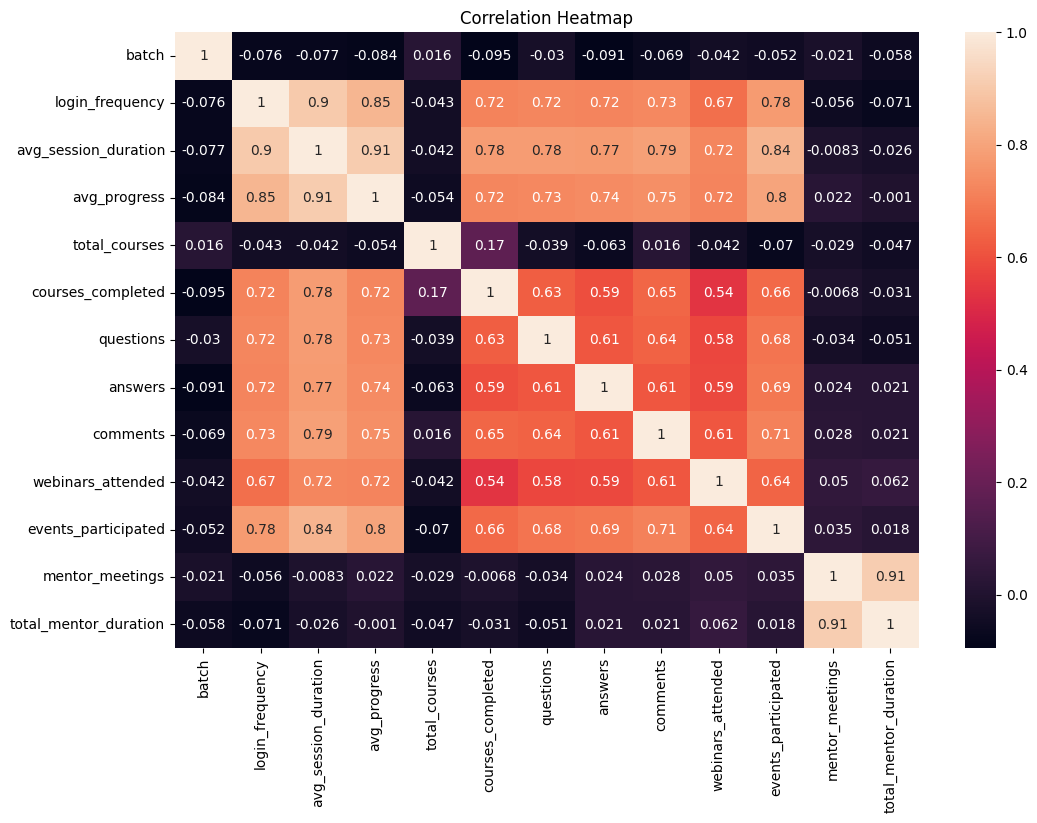

In [24]:
plt.figure(figsize=(12,8))

sns.heatmap(
    summary.select_dtypes(
        include=np.number
    ).corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

1. Dataset successfully cleaned.
2. No major missing values found.
3. No duplicate records found.
4. Student activity data successfully transformed.
5. Department-wise and segment-wise analysis completed.
6. Dataset is ready for KPI creation and dashboard development.